## About the dataset
This datset has 20,640 rows and 8 input features. The target, MedHouseVal, is the median house value for that area, measured in hundreds of thousands of dollars. For example, a target of 2.5 means $250,000.
The features are:
- MedInc: median household income
- HouseAge: median age of houses
- AveRooms: average rooms per household
- AveBedrms: average bedrooms per household
- Population: population in the area
- AveOccup: average number of people per household
- Latitude and Longitude: geographic location

### Import and load the data

In [17]:
import pandas as pd

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

housing = fetch_california_housing(as_frame=True)
housing.frame.to_csv("california_housing.csv", index=False)


In [18]:
df= pd.read_csv("california_housing.csv")
df.head(10)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
5,4.0368,52.0,4.761658,1.103627,413.0,2.139896,37.85,-122.25,2.697
6,3.6591,52.0,4.931907,0.951362,1094.0,2.128405,37.84,-122.25,2.992
7,3.1200,52.0,4.797527,1.061824,1157.0,1.788253,37.84,-122.25,2.414
8,2.0804,42.0,4.294118,1.117647,1206.0,2.026891,37.84,-122.26,2.267
9,3.6912,52.0,4.970588,0.990196,1551.0,2.172269,37.84,-122.25,2.611


In [19]:
print(df.shape)
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

(20640, 9)
Number of rows: 20640
Number of columns: 9


In [20]:
df.info()
df.columns

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal'],
      dtype='str')

## Checking for missing values

In [28]:
print(df.isnull().sum())

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


## Train test split

In [21]:
X = housing.frame.drop(columns=["MedHouseVal"])
y = housing.frame["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training rows:", len(X_train))
print("Test rows:", len(X_test))

Training rows: 16512
Test rows: 4128


## Train the regression model

In [22]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](8,)","[ 0.45, 0.01,-0.12,...,-0. ,-0.42,-0.43]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](8,)","['MedInc','HouseAge','AveRooms',...,'AveOccup','Latitude','Longitude']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-37.02
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(8)


In [25]:
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

Intercept: -37.02327770606416
Coefficients: [ 4.48674910e-01  9.72425752e-03 -1.23323343e-01  7.83144907e-01
 -2.02962058e-06 -3.52631849e-03 -4.19792487e-01 -4.33708065e-01]


inspecting the learned data:

In [26]:
print("Intercept:", model.intercept_)

for feature, coefficient in zip(X.columns, model.coef_):
    print(f"{feature}: {coefficient:.4f}")

Intercept: -37.02327770606416
MedInc: 0.4487
HouseAge: 0.0097
AveRooms: -0.1233
AveBedrms: 0.7831
Population: -0.0000
AveOccup: -0.0035
Latitude: -0.4198
Longitude: -0.4337


- X.columns gives the feature names, such as MedInc or HouseAge.
- model.coef_ gives the coefficient learned for each feature.
- zip(...) pairs them in order: first feature with first coefficient, second feature with second coefficient, and so on.

## Make predictions for the test data

In [27]:
predictions = model.predict(X_test)

comparison = pd.DataFrame({
    "Actual value ($100,000s)": y_test,
    "Predicted value ($100,000s)": predictions
})

display(comparison.head(10))

,"Actual value ($100,000s)","Predicted value ($100,000s)"
20046,0.47700,0.719123
3024,0.45800,1.764017
15663,5.00001,2.709659
20484,2.18600,2.838926
9814,2.78000,2.604657
13311,1.58700,2.011754
7113,1.98200,2.645500
7668,1.57500,2.168755
18246,3.40000,2.740746
5723,4.46600,3.915615


## Model evaluation

In [29]:
mse = mean_squared_error(y_test, predictions)
rmse = mse ** 0.5
r2 = r2_score(y_test, predictions)

print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f} ($100,000s)")
print(f"Approximate RMSE in dollars: ${rmse * 100_000:,.0f}")
print(f"R² score: {r2:.4f}")

MSE: 0.5559
RMSE: 0.7456 ($100,000s)
Approximate RMSE in dollars: $74,558
R² score: 0.5758


- MSE is the average of the squared differences between actual and predicted values. It penalizes large errors more strongly.
- RMSE is the square root of MSE. It is back in the target’s units.
- R² compares the model with a simple baseline that always predicts the average target. 
  A score of 1 means perfect predictions; 0 means roughly the same as that baseline; a negative score means worse than the baseline on this test set.

## Residual v/s actual

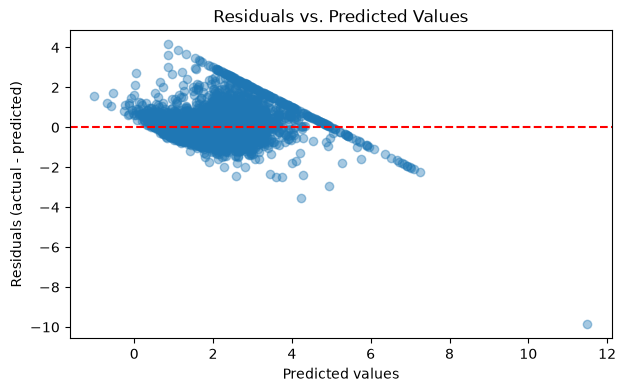

In [30]:
import matplotlib.pyplot as plt
residuals = y_test - predictions

plt.figure(figsize=(7, 4))
plt.scatter(predictions, residuals, alpha=0.4)
plt.axhline(0, color="red", linestyle="--")

plt.xlabel("Predicted values")
plt.ylabel("Residuals (actual - predicted)")
plt.title("Residuals vs. Predicted Values")
plt.show()

A residual is actual minus predicted. This plot helps reveal patterns in the model’s errors. Ideally, the dots are scattered around zero without a clear shape.

observations:
- Above zero: the model predicted too low.
- Below zero: the model predicted too high.
- Near zero: the prediction was close.

## Actual and predicted values for a small sample

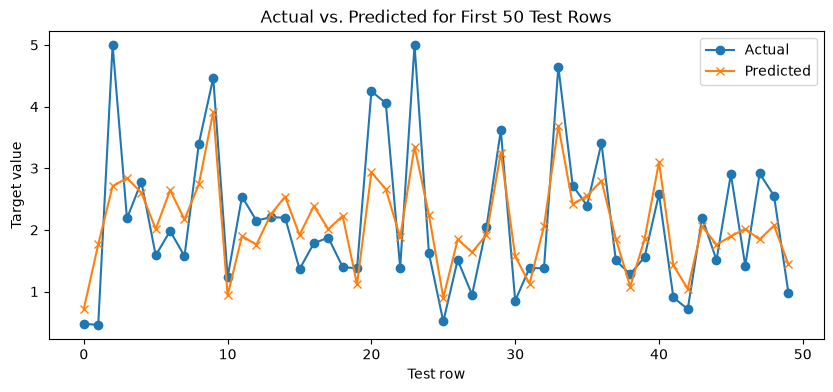

In [31]:
plt.figure(figsize=(10, 4))
plt.plot(y_test.iloc[:50].to_numpy(), label="Actual", marker="o")
plt.plot(predictions[:50], label="Predicted", marker="x")

plt.xlabel("Test row")
plt.ylabel("Target value")
plt.title("Actual vs. Predicted for First 50 Test Rows")
plt.legend()
plt.show()

observations:
- When the actual value is unusually high: such as around test rows 2, 23, and 33, the model predicts a lower value. That’s an underprediction.
- When the actual value is low: such as around rows 0, 1, and 25, the model often predicts a higher value. That’s an overprediction.
Some predictions are fairly close, while others differ noticeably.

## conclusion
- we use California area features to estimate median house value. 
- The test set and metrics show how well those estimates work on data the model didn’t train on.
- Predictions are estimates, so compare them with the actual values and check RMSE and R² to judge how useful the model is.